29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


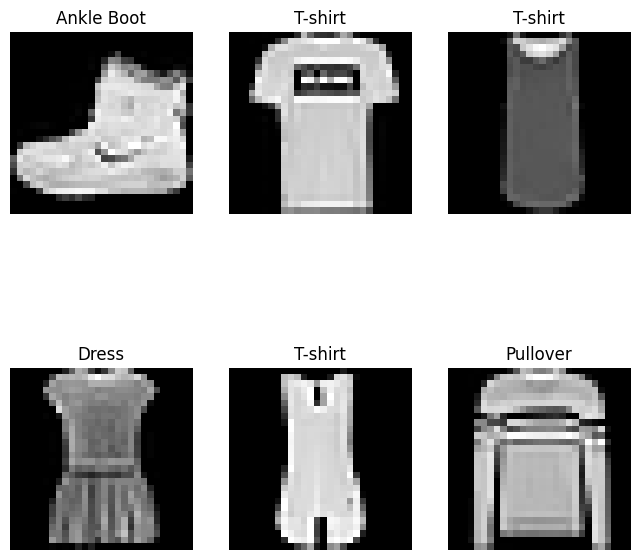

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.7452 - loss: 0.7138 - val_accuracy: 0.8312 - val_loss: 0.4578
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.8343 - loss: 0.4586 - val_accuracy: 0.8588 - val_loss: 0.3767
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.8547 - loss: 0.4043 - val_accuracy: 0.8673 - val_loss: 0.3484
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8643 - loss: 0.3690

Test Loss : 0.36900585889816284
Test Accuracy : 0.864300012588501


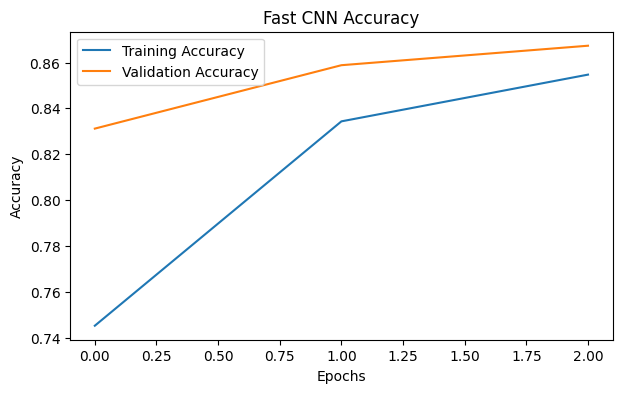

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

Predicted Class : Ankle Boot


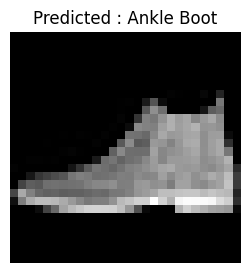

In [1]:
# Experiment No. 5
# Title: Fast Advanced CNN using Keras

# Aim:
# To implement a lightweight Advanced CNN model
# using TensorFlow and Keras for image classification.

# Import Required Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Input
)

# Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize Dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape Dataset
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Class Names
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

# Display Sample Images
plt.figure(figsize=(8,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        X_train[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        class_names[y_train[i]]
    )

    plt.axis('off')

plt.show()

# Build Lightweight CNN Model
model = Sequential([

    Input(shape=(28,28,1)),

    # Convolution Layer 1
    Conv2D(
        16,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    # Convolution Layer 2
    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    # Flatten Layer
    Flatten(),

    # Dense Layer
    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    # Output Layer
    Dense(
        10,
        activation='softmax'
    )
])

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

# Plot Accuracy Graph
plt.figure(figsize=(7,4))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fast CNN Accuracy')
plt.legend()

plt.show()

# Predict Sample
prediction = model.predict(X_test[:1])

predicted_label = np.argmax(prediction)

print(
    "\nPredicted Class :",
    class_names[predicted_label]
)

# Display Prediction
plt.figure(figsize=(3,3))

plt.imshow(
    X_test[0].reshape(28,28),
    cmap='gray'
)

plt.title(
    "Predicted : " + class_names[predicted_label]
)

plt.axis('off')

plt.show()

# Conclusion
# Successfully implemented a lightweight Advanced CNN
# using TensorFlow and Keras for image classification.